## Today's topics

- Log Normal distribution
- Power Law distribution
- Box cox transform

---


# 🔹 Part 1: Log-Normal Distribution

The lognormal distribution, sometimes called the Galton distribution, is a probability distribution whose logarithm has a normal distribution. The lognormal distribution is applicable when the quantity of interest must be positive, because log(x) exists only when x is positive.

A variable follows a Log-Normal distribution if:
- Log of the variable is normally distributed
- Data is positively skewed
- Values are strictly positive

Real-world examples:
- Income distribution
- Stock prices
- Website traffic


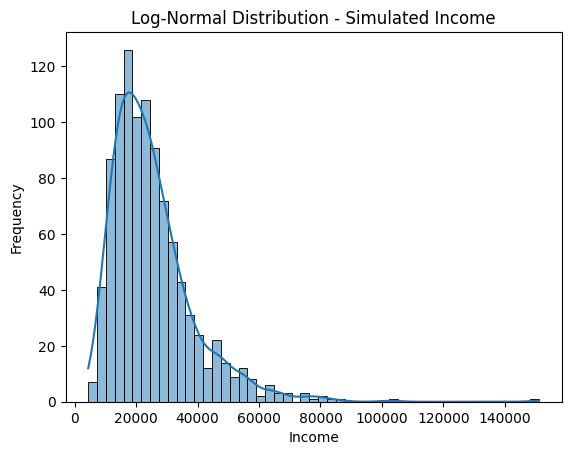

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

income = np.random.lognormal(mean=10, sigma=0.5, size=1000)

# plt.hist(income, bins=30)
sns.histplot(income, kde=True)
plt.title("Log-Normal Distribution - Simulated Income")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()


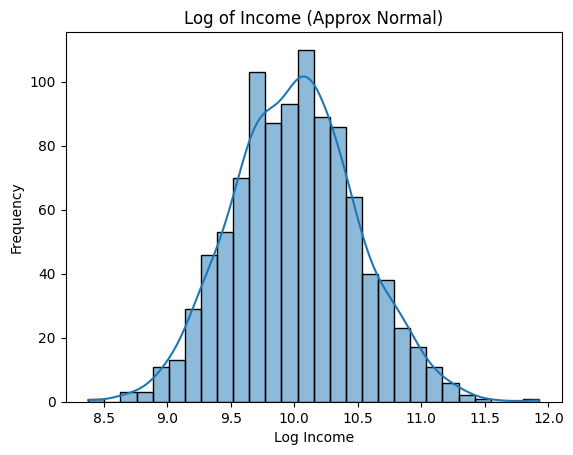

In [2]:

log_income = np.log(income)

# plt.hist(log_income, bins=30)
sns.histplot(log_income, kde=True)
plt.title("Log of Income (Approx Normal)")
plt.xlabel("Log Income")
plt.ylabel("Frequency")
plt.show()


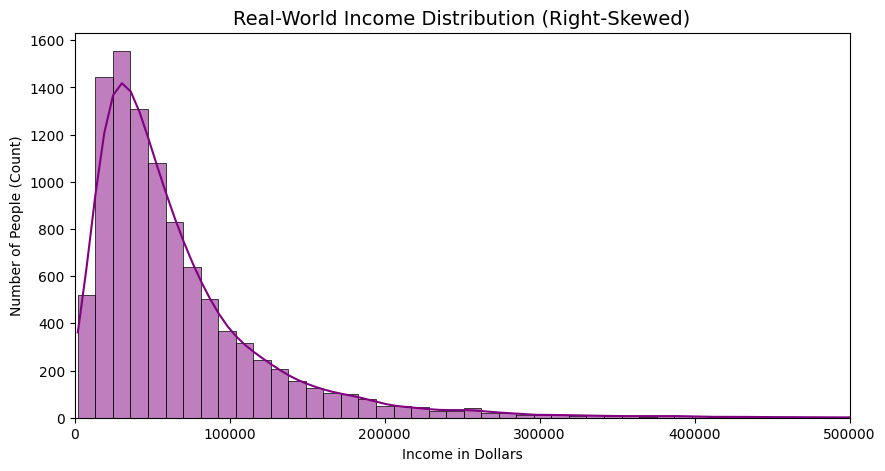

In [3]:
# Simulating Real-World Income Data

# Generate a synthetic dataset of 10,000 salaries following a log-normal distribution
# This mimics real-world census data where most earn average amounts, but some earn vastly more

np.random.seed(42)
income_data = np.random.lognormal(mean=10.8, sigma=0.8, size=10000)
df_large = pd.DataFrame({'Income': income_data})

# Plotting the distribution using Seaborn
plt.figure(figsize=(10, 5))
sns.histplot(df_large['Income'], bins=100, kde=True, color='purple')

plt.title("Real-World Income Distribution (Right-Skewed)", fontsize=14)
plt.xlabel("Income in Dollars")
plt.ylabel("Number of People (Count)")
plt.xlim(0, 500000) # Capping the x-axis to zoom in on the main distribution
plt.show()

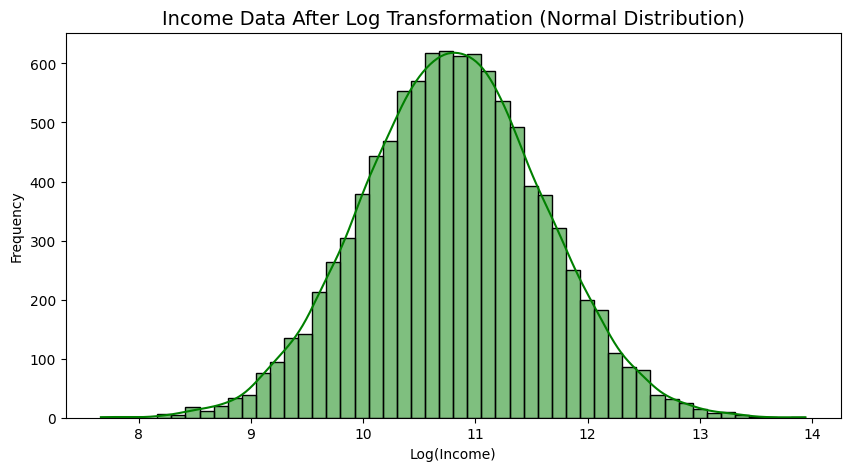

In [4]:
# Applying the Log Transform

# Apply a log transformation to the income column
df_large['Log_Income'] = np.log(df_large['Income'])

# Plotting the transformed distribution
plt.figure(figsize=(10, 5))
sns.histplot(df_large['Log_Income'], bins=50, kde=True, color='green')

plt.title("Income Data After Log Transformation (Normal Distribution)", fontsize=14)
plt.xlabel("Log(Income)")
plt.ylabel("Frequency")
plt.show()


# 🔹 Part 2: Power Law Distribution

A Power Law distribution describes situations where:

Small events are very common
Large events are rare but extremely significant

It follows the form:

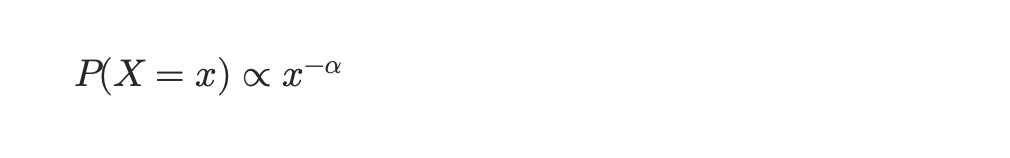

Where:
- α > 1 is the power-law exponent
- Larger α → faster decay
- Heavy tail distribution

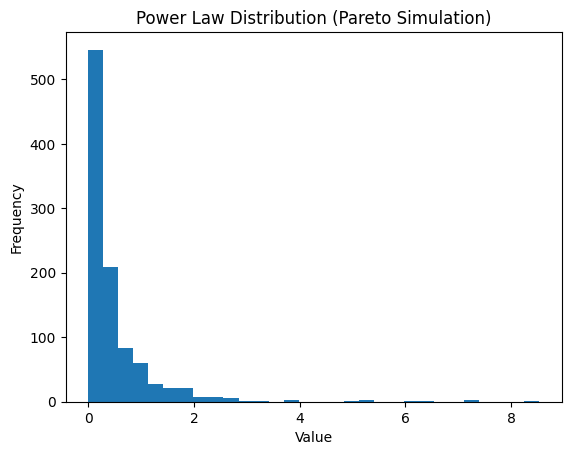

In [5]:

power_law_data = np.random.pareto(a=3, size=1000)

plt.hist(power_law_data, bins=30)
plt.title("Power Law Distribution (Pareto Simulation)")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()


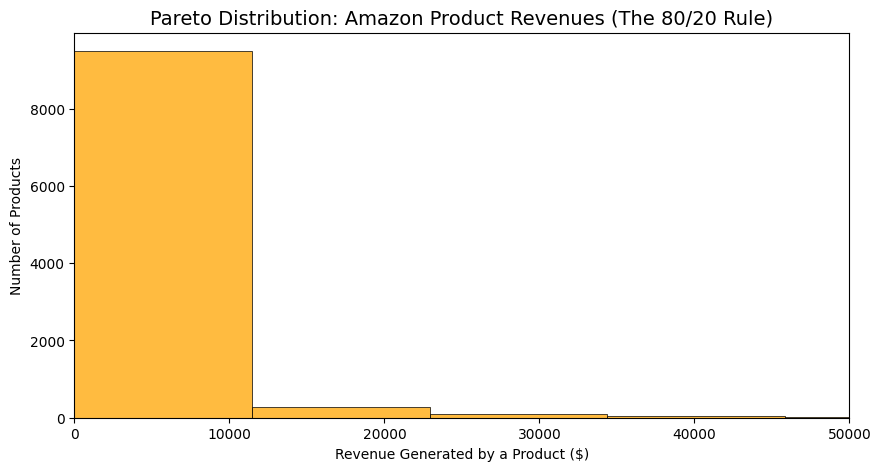

Notice the extreme right-skew: A massive number of products generate very little revenue (the peak on the left),
while a tiny percentage of products stretch out into the long right tail, generating the vast majority of revenue.


In [6]:
# Visualizing the Pareto Distribution


# Simulating the Amazon Product Revenue Example (Pareto Distribution)
# The 'a' parameter defines the shape (alpha). A common value for the 80/20 rule is ~1.16
np.random.seed(42)
alpha = 1.16
sample_size = 10000

# Generate Pareto distributed data representing revenue generated per product
product_revenues = np.random.pareto(alpha, sample_size) * 1000

# Plotting the distribution
plt.figure(figsize=(10, 5))
sns.histplot(product_revenues, bins=100, color='orange', kde=False)

plt.title("Pareto Distribution: Amazon Product Revenues (The 80/20 Rule)", fontsize=14)
plt.xlabel("Revenue Generated by a Product ($)")
plt.ylabel("Number of Products")
plt.xlim(0, 50000) # Capping x-axis to zoom in on the steep drop-off
plt.show()

print("Notice the extreme right-skew: A massive number of products generate very little revenue (the peak on the left),")
print("while a tiny percentage of products stretch out into the long right tail, generating the vast majority of revenue.")




# 🔹 Part 3: Box-Cox Transformation

The Box–Cox transformation is a method used to:

-	Make data more normally distributed
-	Stabilize variance
-	Improve performance of regression models
-	Reduce skewness

⚠️ Works only for **positive values (X > 0)**


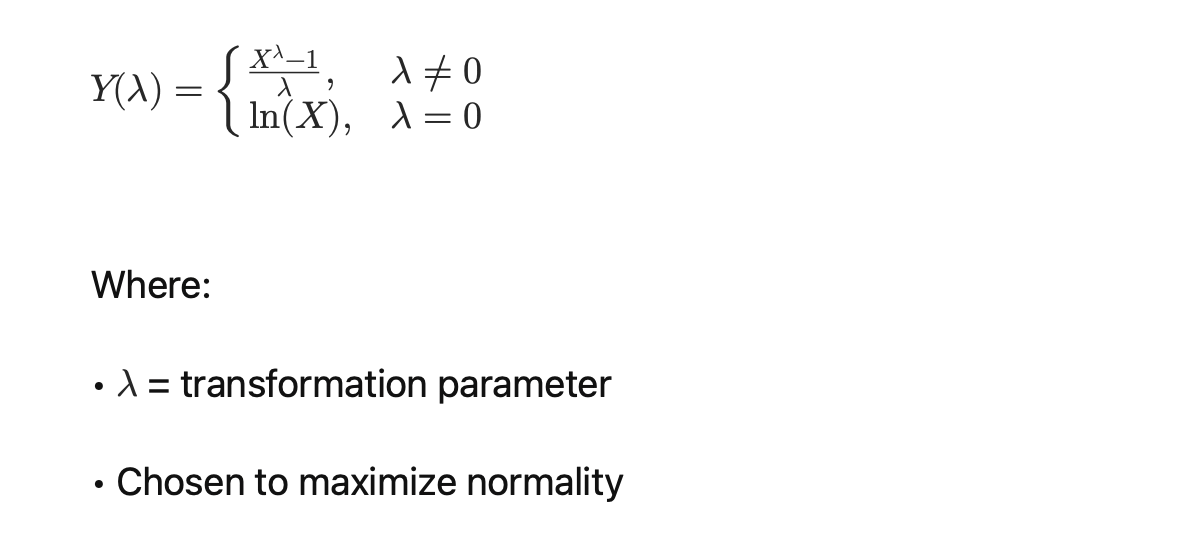

In [14]:

from scipy.stats import boxcox

income_boxcox, _ = boxcox(income)

print(income_boxcox)



[7.04910315 6.90490678 7.08286394 7.27472651 6.88281854 6.88282233
 7.28681813 7.10950009 6.82825944 7.05937627 6.82966998 6.82913156
 6.99168174 6.48229361 6.52854503 6.80660226 6.70034725 7.00803307
 6.72523206 6.60455772 7.26234958 6.88475152 6.95203274 6.60154955
 6.81078632 6.96192161 6.66738645 7.02189729 6.79763036 6.86952417
 6.79738034 7.34520993 6.93352339 6.68966    7.12171685 6.65065471
 6.98417916 6.47085042 6.62485288 6.98145615 7.10306789 6.97566825
 6.91010437 6.86734721 6.58853412 6.76965724 6.83031706 7.17342407
 7.01466377 6.51921177 7.01025461 6.8478835  6.77974452 7.074829
 7.16768936 7.14574404 6.74151372 6.86547064 7.0118755  7.15549604
 6.82599973 6.89399968 6.67805994 6.65656143 7.11949779 7.23867331
 6.92012024 7.1616533  7.01872763 6.78720755 7.01867342 7.27795884
 6.9284123  7.28368513 6.30575713 7.12157459 6.95648285 6.86783226
 6.95755702 6.4639585  6.88615969 7.01770764 7.26499318 6.81688314
 6.74876977 6.82073546 7.14224185 7.01130835 6.81420119 7.052814

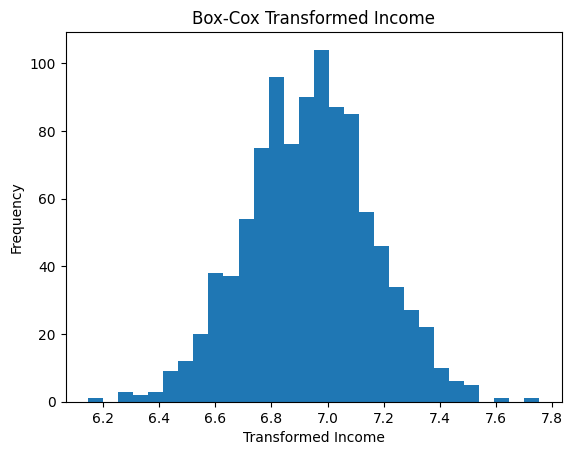

In [8]:

plt.hist(income_boxcox, bins=30)
plt.title("Box-Cox Transformed Income")
plt.xlabel("Transformed Income")
plt.ylabel("Frequency")
plt.show()


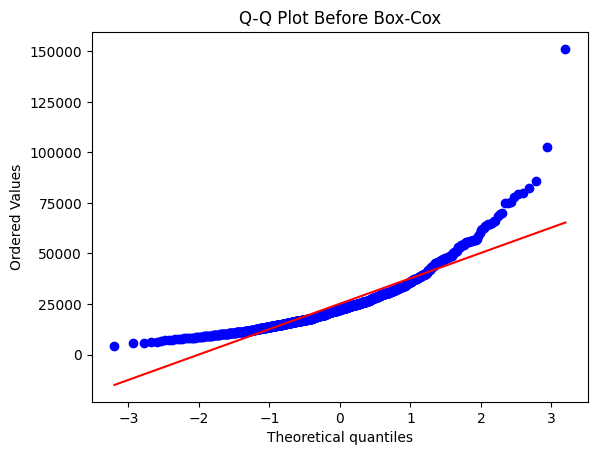

In [9]:

import scipy.stats as stats

stats.probplot(income, dist="norm", plot=plt)
plt.title("Q-Q Plot Before Box-Cox")
plt.show()


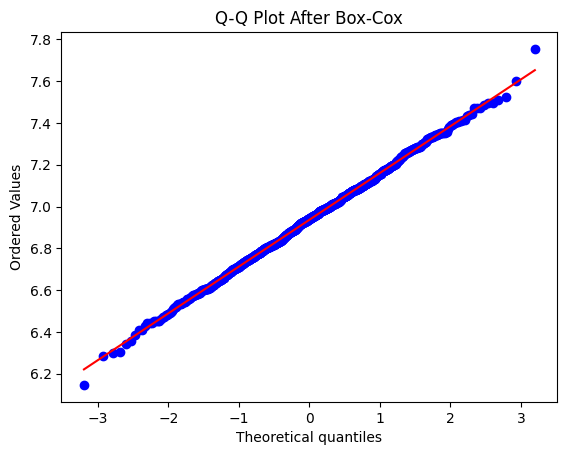

In [10]:

stats.probplot(income_boxcox, dist="norm", plot=plt)
plt.title("Q-Q Plot After Box-Cox")
plt.show()


In [11]:
# Setting up the Concrete Dataset

from sklearn.preprocessing import PowerTransformer

# 1. Simulating the Concrete Dataset mentioned in the lecture
# The dataset predicts concrete strength based on ingredients.
# We include 'Cement' and 'Blast Furnace Slag', which contains zero values.
np.random.seed(42)
data = {
    'Cement': np.random.lognormal(mean=4.5, sigma=0.5, size=1000), # Skewed, positive
    'Blast_Furnace_Slag': np.random.pareto(a=1.5, size=1000) * 10, # Heavily skewed
    'Age': np.random.exponential(scale=30, size=1000)              # Skewed, positive
}

df_concrete = pd.DataFrame(data)

# Injecting zeroes into 'Blast_Furnace_Slag' just like the real dataset
df_concrete.loc[df_concrete.sample(frac=0.2).index, 'Blast_Furnace_Slag'] = 0.0

print("Concrete Dataset (First 5 Rows):")
display(df_concrete.head())

print("\nAbout Dataset:")
print(df_concrete.describe())


Concrete Dataset (First 5 Rows):


,Cement,Blast_Furnace_Slag,Age
0,115.394544,1.299809,7.418047
1,84.004288,0.764112,1.122377
2,124.442563,9.630959,3.429541
3,192.773308,0.000000,12.413719
4,80.071766,0.216277,48.673518



About Dataset:
            Cement  Blast_Furnace_Slag          Age
count  1000.000000         1000.000000  1000.000000
mean    102.706001           13.502627    29.197559
std      55.557707           35.557428    28.359746
min      17.802988            0.000000     0.000349
25%      65.118275            0.478088     8.892639
50%      91.163116            3.772249    20.301151
75%     124.458455           11.384854    40.254420
max     617.924169          440.866679   183.864690


In [12]:
# Box-Cox Implementation

# Create the Box-Cox transformer
pt_boxcox = PowerTransformer(method='box-cox')

# We MUST add a small constant to handle the zeros in 'Blast_Furnace_Slag'
df_boxcox_input = df_concrete + 0.0001

# Apply the transformation
transformed_boxcox = pt_boxcox.fit_transform(df_boxcox_input)

# Convert back to a DataFrame for easy viewing
df_transformed_boxcox = pd.DataFrame(transformed_boxcox, columns=df_concrete.columns)

print("Box-Cox Transformed Data:")
display(df_transformed_boxcox.head())

Box-Cox Transformed Data:


,Cement,Blast_Furnace_Slag,Age
0,0.502914,-0.179326,-0.776335
1,-0.142559,-0.337698,-1.741372
2,0.654039,0.565121,-1.235977
3,1.512881,-1.644364,-0.406185
4,-0.241433,-0.661071,0.896299


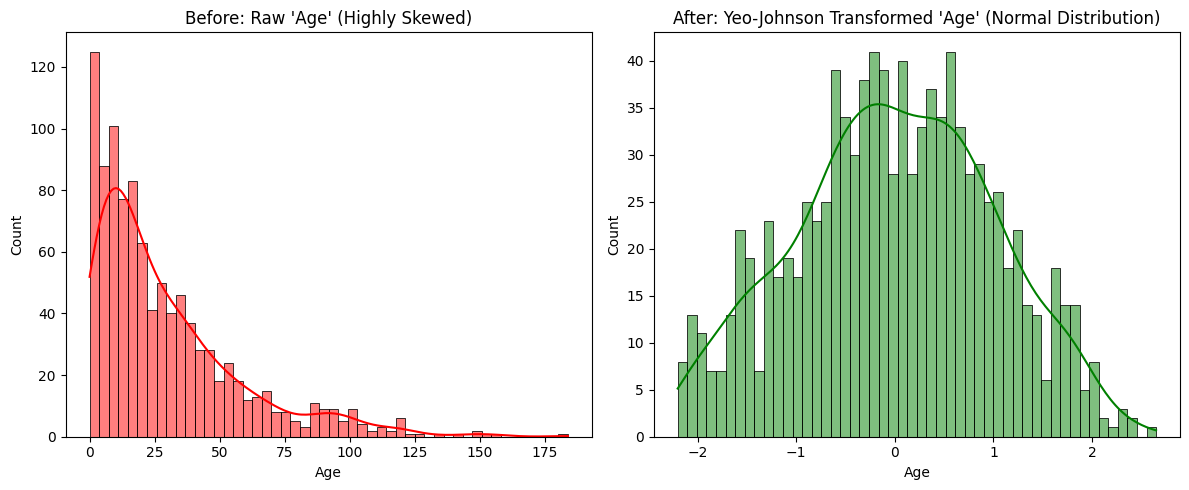

In [13]:
# Yeo-Johnson Implementation

# Create the Yeo-Johnson transformer (This is the default method)
pt_yeo = PowerTransformer(method='yeo-johnson')

# We do NOT need to add a constant; Yeo-Johnson handles the zeros natively
transformed_yeo = pt_yeo.fit_transform(df_concrete)

df_transformed_yeo = pd.DataFrame(transformed_yeo, columns=df_concrete.columns)

# Visualizing the difference: Before vs. After Yeo-Johnson
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before Transform
sns.histplot(df_concrete['Age'], bins=50, color='red', kde=True, ax=axes[0])
axes[0].set_title("Before: Raw 'Age' (Highly Skewed)")

# After Transform
sns.histplot(df_transformed_yeo['Age'], bins=50, color='green', kde=True, ax=axes[1])
axes[1].set_title("After: Yeo-Johnson Transformed 'Age' (Normal Distribution)")

plt.tight_layout()
plt.show()

**For more Reference:**

1. Log normal distribution - https://youtu.be/5LPFJ-cBSyY
2. Power law distribution - https://youtu.be/zfTMpoFKNEg
3. Pareto distribution - https://youtu.be/SF2dLUB6t28
4. Box-Cox transformation & Yeo-Johnson transformation - https://youtu.be/lV_Z4HbNAx0


# 📝 Practice Questions

1. What is Log-Normal distribution?
2. Why does income often follow Log-Normal distribution?
3. What is Power Law distribution?
4. What does heavy-tailed mean?
5. What is Box-Cox transformation used for?
6. Why must data be positive for Box-Cox?
7. How does Box-Cox help in regression?



# 📌 Mini Assignment

Scenario:
An e-commerce platform records daily seller revenue which is highly skewed.

Tasks:
1. Simulate log-normal revenue data.
2. Plot histogram.
3. Apply Box-Cox transformation.
4. Compare Q-Q plots before and after transformation.
5. Simulate power-law follower distribution.
6. Compare log-normal vs power-law visually.
7. Provide business interpretation.
